# Ensemble Model: Milestone 3, refining for best model

Combination of Random Forest and XGBoost base models with a shared canonical split. We got rid of KNN as not useful/ impossible to run.

Next step: build meta-model on top.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Data & Split
80/20 split

In [2]:
df = pd.read_csv('../kickstarter_clean.csv')

X = df.drop(columns=['State'])
y = df['State']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Class distribution (test): {y_test.value_counts().to_dict()}")

Train: 262,658 | Test: 65,665
Class distribution (test): {0: 38925, 1: 26740}


## Random Forest
Tuned model from Alexander: max_depth=25, n_estimators=100, min_samples_split=20, max_features=0.3

In [3]:
rf = RandomForestClassifier(
    max_depth=25,
    n_estimators=100,
    min_samples_split=20,
    max_features=0.3,
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print(classification_report(y_test, rf_preds))
print(f"Weighted F1: {f1_score(y_test, rf_preds, average='weighted'):.4f}")

              precision    recall  f1-score   support

           0       0.71      0.81      0.76     38925
           1       0.65      0.52      0.58     26740

    accuracy                           0.69     65665
   macro avg       0.68      0.67      0.67     65665
weighted avg       0.69      0.69      0.69     65665

Weighted F1: 0.6853


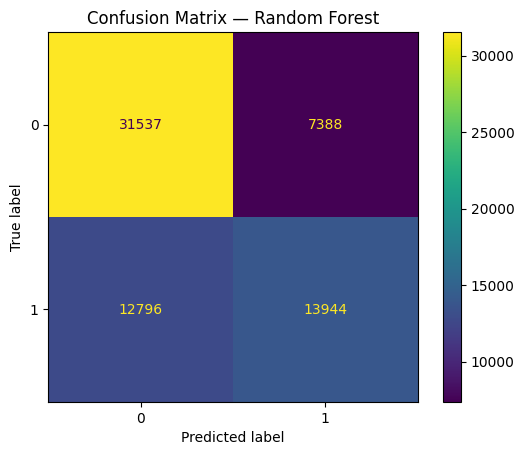

In [4]:
cm = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Confusion Matrix — Random Forest')
plt.show()

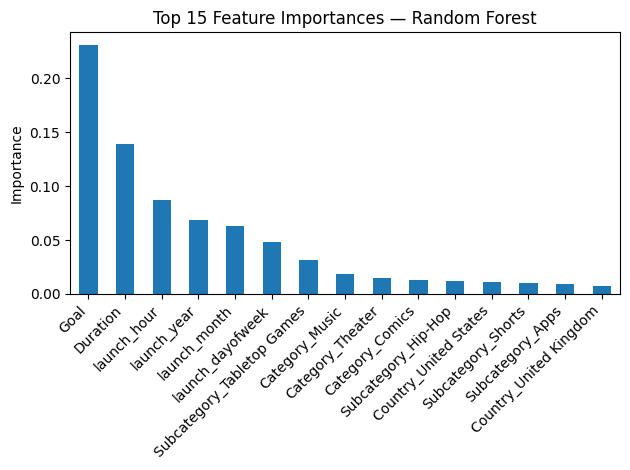

In [5]:
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
rf_importance.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## XGBoost
Tuned model from Ori: best params from RandomizedSearchCV (100 iter, 5-fold CV).

In [36]:
xgb = XGBClassifier(
    n_estimators=1200,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.2,
    reg_lambda=1.2,
    scale_pos_weight=1.2,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print(classification_report(y_test, xgb_preds))
print(f"Weighted F1: {f1_score(y_test, xgb_preds, average='weighted'):.4f}")

              precision    recall  f1-score   support

           0       0.75      0.74      0.74     38925
           1       0.63      0.63      0.63     26740

    accuracy                           0.70     65665
   macro avg       0.69      0.69      0.69     65665
weighted avg       0.70      0.70      0.70     65665

Weighted F1: 0.6983


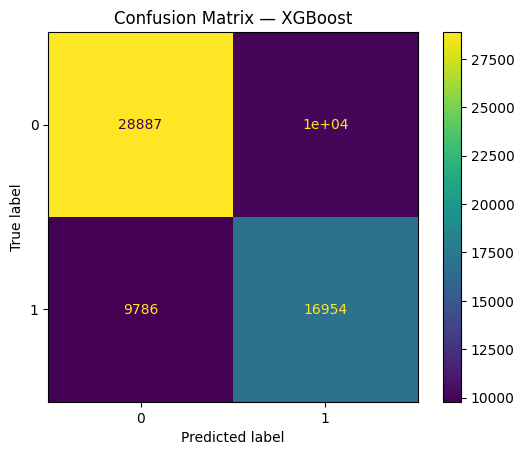

In [7]:
cm = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Confusion Matrix — XGBoost')
plt.show()

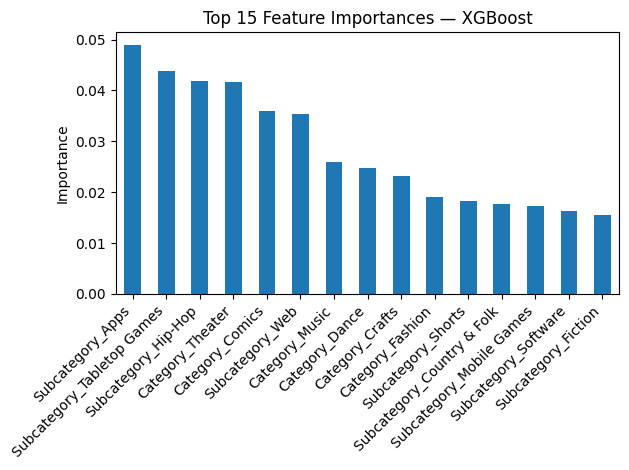

In [8]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
xgb_importance.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances — XGBoost')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Model Comparison

In [35]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'F1 Weighted': [
        f1_score(y_test, rf_preds, average='weighted'),
        f1_score(y_test, xgb_preds, average='weighted')
    ],
    'F1 Class 0 (Failed)': [
        f1_score(y_test, rf_preds, average=None)[0],
        f1_score(y_test, xgb_preds, average=None)[0]
    ],
    'F1 Class 1 (Successful)': [
        f1_score(y_test, rf_preds, average=None)[1],
        f1_score(y_test, xgb_preds, average=None)[1]
    ]
}).set_index('Model').round(4)

results


,Accuracy,F1 Weighted,F1 Class 0 (Failed),F1 Class 1 (Successful)
Model,,,,
Random Forest,0.6926,0.6853,0.7576,0.5801
XGBoost,0.6981,0.6983,0.7445,0.6311


---
## Next Steps
- Error analysis
- Ensemble: Voting classifier
- Ensemble: Stacking with meta-model
- Pick best overall model
- Compare all metrics against baseline

 ## Error Analysis
 
 The goal of error analysis is to understand *where* and *why* our models fail. 
 
 ### Steps

 **1. Build the error DataFrame** --> Add the true labels and both models' predictions to a copy of X_test, then filter for misclassified rows. This gives us a focused dataset of mistakes to investigate. 

 **2. Break down errors by type** --> Separate false negatives (predicted Failed, actually Successful) from false positives (predicted Successful, actually Failed). This tells us which mistake each model makes more often and how the two models compare.                      
                  
 **3. Compare feature distributions** --> For key features from each model compare the distribution of errors vs correct predictions. This reveals whether the model struggles in specific regions of the data (e.g. low-goal, sucategory fashion, etc).

 **4. Find where both models agree on the wrong answer** --> These are the hardest cases, if both RF and XGBoost misclassify the same samples, it likely points to noise in the data or missing features rather than a model-specific weakness. 

 **5. Look for patterns in errors** --> Check if errors cluster around specific values or time periods. This can inform feature engineering decisions for future iterations.

In [10]:
# Building the error DF:

edf = X_test.copy()
edf['true_label'] = y_test.values # .values to get rid of pandas index and get a np array
edf['rf_prediction'] = rf_preds
edf['xgb_prediction'] = xgb_preds


In [16]:
# Filtering the errors:

errors = edf[
    (edf['rf_prediction'] != edf['true_label']) |
    (edf['xgb_prediction'] != edf['true_label'])]

# Have a look at the errors:

print(f'Total errors: {len(errors)} out of {len(edf)} ({len(errors)/len(edf) * 100:.1f}%)') #:.1 to format the output to just one decimal
print(errors[['rf_prediction', 'xgb_prediction', 'true_label']].value_counts())

Total errors: 23927 out of 65665 (36.4%)
rf_prediction  xgb_prediction  true_label
0              0               1             9337
1              1               0             6744
0              1               1             3459
                               0             3294
1              0               0              644
                               1              449
Name: count, dtype: int64


Results:

1. **Overall error rate is 36.4%**
 Both models combined get 23,927 out of 65,665 test cases wrong.

2. **The hardest cases are where both models fail together**
 16,081 errors (67%) come from cases where RF and XGBoost both predict the wrong label (the noise).

3. **False negatives are the biggest single problem**
 9,337 cases where both models predicted failure but the project actually succeeded. The models struggle most to identify what makes a project succeed.

4. **XGBoost is slightly more reliable than RF on solo errors**
 When only one model is wrong, RF fails 4,103 (3459 + 644) times vs XGBoost 3,743 (3294 + 449) times.

5. **This justifies the ensemble approach**
The 7,846 (4,103 (RF solo errors) + 3,743 (XGBoost solo errors)) cases where only one model is wrong are potentially recoverable by combining both models.

In [22]:
#Filtering the errors by type and model:

#  RF errors
rf_fn = edf[(edf['rf_prediction'] == 0) & (edf['true_label'] == 1)]  # predicted fail, actually success
rf_fp = edf[(edf['rf_prediction'] == 1) & (edf['true_label'] == 0)]  # predicted success, actually fail

# XGB errors
xgb_fn = edf[(edf['xgb_prediction'] == 0) & (edf['true_label'] == 1)]
xgb_fp = edf[(edf['xgb_prediction'] == 1) & (edf['true_label'] == 0)]

print(" Random Forest ")
print(f"False Negatives (missed successes): {len(rf_fn)}")
print(f"False Positives (false alarms):     {len(rf_fp)}")
print(f'Random Forest errors in total: {len(rf_fp) + len(rf_fn)}')

print(" XGBoost ")
print(f"False Negatives (missed successes): {len(xgb_fn)}")
print(f"False Positives (false alarms):     {len(xgb_fp)}")
print(f'XGBoost errors in total: {len(xgb_fn) + len(xgb_fp)}')

 Random Forest 
False Negatives (missed successes): 12796
False Positives (false alarms):     7388
Random Forest errors in total: 20184
 XGBoost 
False Negatives (missed successes): 9786
False Positives (false alarms):     10038
XGBoost errors in total: 19824


These totals are larger than the 23,927 errors that were outputted in the cell before. That's because when both models are wrong on the same row, it gets counted once in 23,927 but contributes to both models' individual totals. The analysis result from this is that:

* XGBoost makes fewer total errors (19,824 vs 20,184), confirming it's the stronger model

* Their error types are opposite: RF misses more successes, XGBoost raises more false alarms

Top 10 RF (test) features:
Goal                          0.231198
Duration                      0.138968
launch_hour                   0.086989
launch_year                   0.068887
launch_month                  0.063337
launch_dayofweek              0.048584
Subcategory_Tabletop Games    0.031905
Category_Music                0.018388
Category_Theater              0.014775
Category_Comics               0.013368
dtype: float64

Top 10 XGBoost (test) features:
Subcategory_Apps              0.048980
Subcategory_Tabletop Games    0.043733
Subcategory_Hip-Hop           0.041930
Category_Theater              0.041635
Category_Comics               0.036052
Subcategory_Web               0.035475
Category_Music                0.025879
Category_Dance                0.024828
Category_Crafts               0.023205
Category_Fashion              0.019038
dtype: float32


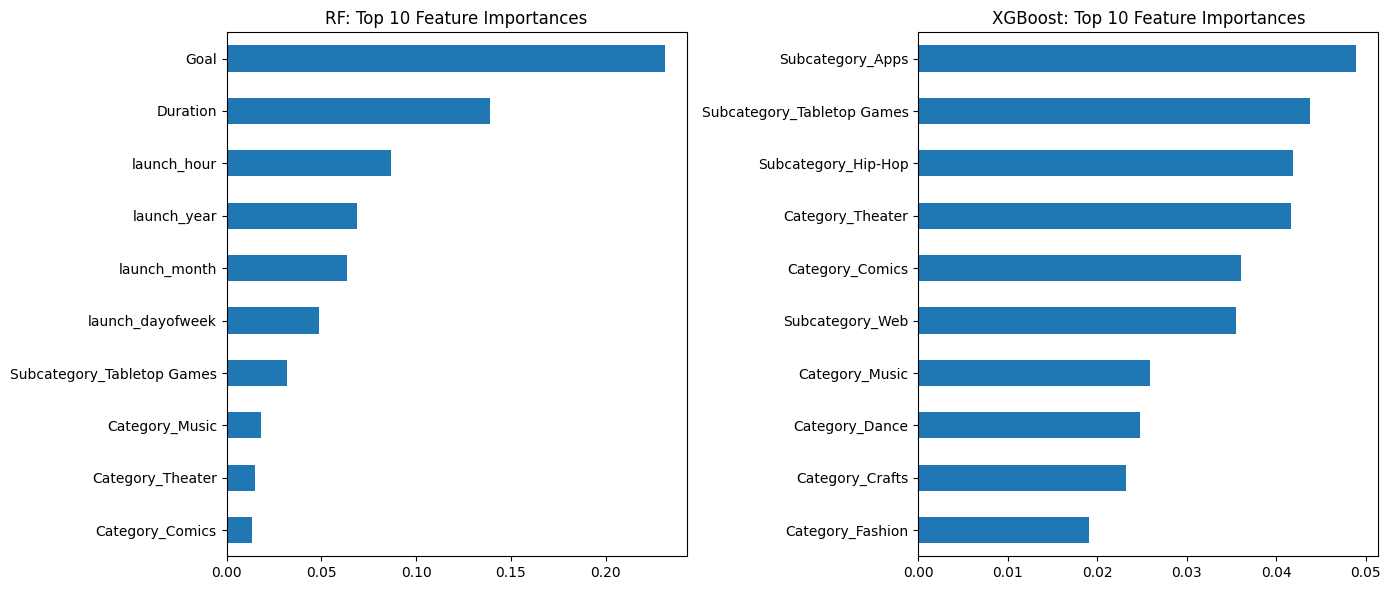

In [ ]:
# Get feature importance (variables pre-defined) to compare both models again:

# Top 10 for each
top10_rf = rf_importance.sort_values(ascending=False).head(10) # ascending=False because we want the most important first
top10_xgb = xgb_importance.sort_values(ascending=False).head(10)

print("Top 10 RF (test) features:")
print(top10_rf)
print("\nTop 10 XGBoost (test) features:")
print(top10_xgb)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10_rf.sort_values().plot(kind='barh', ax=axes[0], title='RF: Top 10 Feature Importances')
top10_xgb.sort_values().plot(kind='barh', ax=axes[1], title='XGBoost: Top 10 Feature Importances')

plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

Key Finding:

The two models learn different patterns from the same data:
 * **RF** is driven by numerical features: Goal alone accounts for ~23% of the decision, followed by temporal features like Duration and launch_hour. Categories barely appear in the top features.

 * **XGBoost** is driven by categorical features: Goal and Duration don't appear in the top 10 at all. Importance scores are also more evenly distributed (0.02–0.05) compared to RF's dominant Goal feature (0.23).

This means:
- RF asks: "How much money are you asking for, and for how long?"
- XGBoost asks: "What kind of project is this?"

In [ ]:
# Plots for feature distribution error vs correct in each model

## Ensemble the models

### Steps:

1. **Voting Classifier:**

 * Train the Voting Classifier (soft voting) on both models
 * Evaluate with classification report
 * Compare FP and FN from the ensemble vs RF and XGBoost individually

2. **Stacking Classifier:**

 * Train the Stacking Classifier with Logistic Regression as meta-model
 * Evaluate with classification report
 * Compare FP and FN vs previous models

3. **Pick best overall model:**

 * Build a final comparison table: all models side by side (accuracy, precision, recall, F1 macro)
 * Identify the winner based on F1 macro

4. **Compare all metrics against baseline:**

 * Add baseline to the table
 * Show improvement delta: how much better is the best model vs baseline?

### 1. Voting Calssifier:

In [ ]:
# Train both models on the voting classifier:

# from sklearn.ensemble import VotingClassifier

# The voting classifier wasn't recognising the xbg as a classifier, so I duplicate the xgb classifier and change some parameters:

# xgb2 = XGBClassifier(
    n_estimators=1200,        # 1st intent
    learning_rate=0.06,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.2,
    reg_lambda=1.2,
    scale_pos_weight=1.2,
    n_jobs=-1,
    random_state=42
)
# xgb2.fit(X_train, y_train)

#Still didn't work so, trying with wrapping the classifier in a pipeline:

from sklearn.pipeline import make_pipeline                                                                            
                                                                                                                        
# xgb_pipe = make_pipeline(xgb2)  --> didn't work, 2nd intent

# xgb2._estimator_type = "classifier"  --> didn't work, 3rd intent

# voting = VotingClassifier(
    estimators=[
        ('rf', rf),    #tuple: name (str), estimator (the model)
        ('xgb', xgb2),
    ],
    voting='soft'
)

# voting.fit(X_train, y_train)
# y_pred_voting = voting.predict(X_test)

# print("Voting Classifier")
# print(classification_report(y_test, y_pred_voting))

ValueError: The estimator XGBClassifier should be a classifier.

XGBoost 2.0.3 doesn't set _estimator_type, which sklearn 1.8.0 now strictly requires. Quickest fix is to skip VotingClassifier and implement soft voting manually:   

In [42]:
rf_proba = rf.predict_proba(X_test)  # predict_proba() is a standard scikit-learn method available on any classifier that outputs probabilities                                                                                  
xgb_proba = xgb.predict_proba(X_test)                                                                                 
                                                                                                                        
avg_proba = (rf_proba + xgb_proba) / 2                                                                                
y_pred_voting = np.argmax(avg_proba, axis=1)  # picks the class with the highest averaged probability for each row. axis=1 means "look across columns per row".                                                                        
                                                                                                                        
print("Voting Classifier")                                                                                            
print(classification_report(y_test, y_pred_voting))                                  

Voting Classifier
              precision    recall  f1-score   support

           0       0.73      0.78      0.76     38925
           1       0.65      0.58      0.61     26740

    accuracy                           0.70     65665
   macro avg       0.69      0.68      0.68     65665
weighted avg       0.70      0.70      0.70     65665



In [45]:
# Compare ensemble with the others individually:

results2 = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Voting Classifier'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, y_pred_voting)
    ],
    'F1 Weighted': [
        f1_score(y_test, rf_preds, average='weighted'),
        f1_score(y_test, xgb_preds, average='weighted'),
        f1_score(y_test, y_pred_voting, average='weighted')
    ],
    'F1 Class 0 (Failed)': [
        f1_score(y_test, rf_preds, average=None)[0],
        f1_score(y_test, xgb_preds, average=None)[0],
        f1_score(y_test, y_pred_voting, average=None)[0]
    ],
    'F1 Class 1 (Successful)': [
        f1_score(y_test, rf_preds, average=None)[1],
        f1_score(y_test, xgb_preds, average=None)[1],
        f1_score(y_test, y_pred_voting, average=None)[1]
    ]
}).set_index('Model').round(4)

results2

,Accuracy,F1 Weighted,F1 Class 0 (Failed),F1 Class 1 (Successful)
Model,,,,
Random Forest,0.6926,0.6853,0.7576,0.5801
XGBoost,0.6981,0.6983,0.7445,0.6311
Voting Classifier,0.6998,0.6970,0.7550,0.6125


Results:

The Voting Classifier slightly improves accuracy over both individual models but doesn't outperform XGBoost on F1. A different solution will be Stacking. It could be a smarter combination that learns how to weight the models rather than just averaging them.

### 2. Stacking Classifier:

Stacking is an ensemble technique that trains a **meta-model** on top of the predictions of the base models. Instead of averaging predictions (like Voting), the meta-model learns how to best combine the base models' outputs.

The meta-model's input is simple just the outputs of RF and XGBoost (2 columns), not the original 203 features. Its job isn't to learn from raw data but to learn how much to trust each base model. For this reason we can keep it simple:

- **Logistic Regression** is fast, interpretable, and unlikely to overfit on such a small input
- A complex meta-model would risk overfitting on the base models' predictions

We use **cv=3** inside the StackingClassifier to ensure the meta-model is trained on out-of-fold predictions, predictions the base models made on data they hadn't seen. This prevents data leakage between the base models and the meta-model.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Build the stacking classifier

stacking = StackingClassifier(
    estimators=[
        ('rf', rf),   # base model 1: RF pulled from results dict
        ('xgb', xgb),        # base model 2: XGBoost pulled from results dict
    ],
    final_estimator=LogisticRegression(),  # meta-model: learns how to combine RF and XGBoost outputs, 2 features
    cv=3                                   # 3-fold cross validation to generate the meta-model's training data
                                           # avoids the meta-model seeing predictions on data it was trained on
)

# Train the full stacking pipeline on the training data
# internally: first trains RF and XGBoost, then trains LogisticRegression on their outputs
stacking.fit(X_train, y_train)

# Generate predictions on the test set
stacking_preds = stacking.predict(X_test)

# Evaluate
print("Stacking Classifier")
print(classification_report(y_test, stacking_preds))

--- Stacking Classifier ---
              precision    recall  f1-score   support

           0       0.73      0.80      0.76     38925
           1       0.65      0.56      0.61     26740

    accuracy                           0.70     65665
   macro avg       0.69      0.68      0.68     65665
weighted avg       0.70      0.70      0.70     65665



Adding it to the results df:

In [48]:
results3 = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Voting Classifier', 'Stacking Classifier'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, y_pred_voting),
        accuracy_score(y_test, stacking_preds)
    ],
    'F1 Weighted': [
        f1_score(y_test, rf_preds, average='weighted'),
        f1_score(y_test, xgb_preds, average='weighted'),
        f1_score(y_test, y_pred_voting, average='weighted'),
        f1_score(y_test, stacking_preds, average='weighted')
    ],
    'F1 Class 0 (Failed)': [
        f1_score(y_test, rf_preds, average=None)[0],
        f1_score(y_test, xgb_preds, average=None)[0],
        f1_score(y_test, y_pred_voting, average=None)[0],
        f1_score(y_test, stacking_preds, average=None)[0]
    ],
    'F1 Class 1 (Successful)': [
        f1_score(y_test, rf_preds, average=None)[1],
        f1_score(y_test, xgb_preds, average=None)[1],
        f1_score(y_test, y_pred_voting, average=None)[1],
        f1_score(y_test, stacking_preds, average=None)[1]
    ]
}).set_index('Model').round(4)

results3

,Accuracy,F1 Weighted,F1 Class 0 (Failed),F1 Class 1 (Successful)
Model,,,,
Random Forest,0.6926,0.6853,0.7576,0.5801
XGBoost,0.6981,0.6983,0.7445,0.6311
Voting Classifier,0.6998,0.6970,0.7550,0.6125
Stacking Classifier,0.7013,0.6970,0.7595,0.6060


Results:
 * Stacking wins on Accuracy (0.7013) and F1 Class 0 (0.7595) —-> best at identifying failed projects.
 * XGBoost wins on F1 Weighted (0.6983) and F1 Class 1 (0.6311) —-> best at identifying successful projects.

## Model Comparison & Final Decision

### Key Observations

- **Stacking** achieves the highest accuracy (0.7013) and best F1 on failed projects (0.7595)
- **XGBoost** is the most balanced model, best F1 Weighted (0.6983) and best at identifying successful projects (0.6311)
- **Voting** sits between the two individual models on all metrics, as expected from a simple average between 2 models
- **Random Forest** is the weakest overall, though it has the second best F1 on failed projects

### Decision --> **XGBoost** as our best overall model

The core business question is: *"Will this Kickstarter project succeed?"* 

From a creator's perspective, correctly identifying successful projects (Class 1) is more valuable than correctly identifying failures. A false negative, telling a creator their project will fail when it would have succeeded, is a more costly mistake than a false positive.

XGBoost scores highest on F1 Weighted (0.6983) and F1 Class 1 (0.6311), meaning it is the most balanced model and the best at identifying successful projects. While Stacking achieves marginally higher accuracy (+0.003), it sacrifices performance on Class 1 to get there, which goes against our primary objective.

## Comparison to the Baseline Model

In [52]:
# Fetching the baseline model and creating the predictions variable:

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)
print(classification_report(y_test, tree_preds))

              precision    recall  f1-score   support

           0       0.69      0.79      0.74     38925
           1       0.61      0.49      0.55     26740

    accuracy                           0.67     65665
   macro avg       0.65      0.64      0.64     65665
weighted avg       0.66      0.67      0.66     65665



Adding the baseline model to the results table to compare:

In [54]:
results4 = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Voting Classifier', 'Stacking Classifier', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, y_pred_voting),
        accuracy_score(y_test, stacking_preds),
        accuracy_score(y_test, tree_preds)
    ],
    'F1 Weighted': [
        f1_score(y_test, rf_preds, average='weighted'),
        f1_score(y_test, xgb_preds, average='weighted'),
        f1_score(y_test, y_pred_voting, average='weighted'),
        f1_score(y_test, stacking_preds, average='weighted'),
        f1_score(y_test, tree_preds, average='weighted')
    ],
    'F1 Class 0 (Failed)': [
        f1_score(y_test, rf_preds, average=None)[0],
        f1_score(y_test, xgb_preds, average=None)[0],
        f1_score(y_test, y_pred_voting, average=None)[0],
        f1_score(y_test, stacking_preds, average=None)[0],
        f1_score(y_test, tree_preds, average=None)[0]
    ],
    'F1 Class 1 (Successful)': [
        f1_score(y_test, rf_preds, average=None)[1],
        f1_score(y_test, xgb_preds, average=None)[1],
        f1_score(y_test, y_pred_voting, average=None)[1],
        f1_score(y_test, stacking_preds, average=None)[1],
        f1_score(y_test, tree_preds, average=None)[1]
    ]
}).set_index('Model').round(4)

results4

,Accuracy,F1 Weighted,F1 Class 0 (Failed),F1 Class 1 (Successful)
Model,,,,
Random Forest,0.6926,0.6853,0.7576,0.5801
XGBoost,0.6981,0.6983,0.7445,0.6311
Voting Classifier,0.6998,0.6970,0.7550,0.6125
Stacking Classifier,0.7013,0.6970,0.7595,0.6060
Decision Tree,0.6667,0.6592,0.7364,0.5469


In [55]:
# Checking the improvement:

baseline = results4.loc['Decision Tree']
best_model = results4.loc['XGBoost']

delta = (best_model - baseline).round(4)
print("Improvement of XGBoost over Decision Tree baseline:")
print(delta)

Improvement of XGBoost over Decision Tree baseline:
Accuracy                   0.0314
F1 Weighted                0.0391
F1 Class 0 (Failed)        0.0081
F1 Class 1 (Successful)    0.0842
dtype: float64


## Final Interpretation

Every model outperforms the Decision Tree baseline across all metrics. The most significant improvement is on **F1 Class 1 (Successful)**, XGBoost improves by +0.0842 over the baseline. This is the most business-relevant metric for a Kickstarter prediction tool.

The progression from Decision Tree → Random Forest → XGBoost tells a clear story: 

Each step up in model complexity brings consistent gains, with the biggest jump coming from moving to XGBoost. The ensemble methods (Voting, Stacking) provide marginal accuracy gains but don't improve on XGBoost's ability to identify successful projects, reinforcing our choice of XGBoost as the final model.